### Ejercicio 2- Clasificación - Regresión logística

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

dat_csv = pd.read_csv('usuarios_win_mac_lin.csv', encoding= 'iso-8859-1')
dat_csv.head()
dat_csv.describe()

,duracion,paginas,acciones,valor,clase
count,170.000000,170.000000,170.000000,170.000000,170.000000
mean,111.075729,2.041176,8.723529,32.676471,0.752941
std,202.453200,1.500911,9.136054,44.751993,0.841327
min,1.000000,1.000000,1.000000,1.000000,0.000000
25%,11.000000,1.000000,3.000000,8.000000,0.000000
50%,13.000000,2.000000,6.000000,20.000000,0.000000
75%,108.000000,2.000000,10.000000,36.000000,2.000000
max,898.000000,9.000000,63.000000,378.000000,2.000000


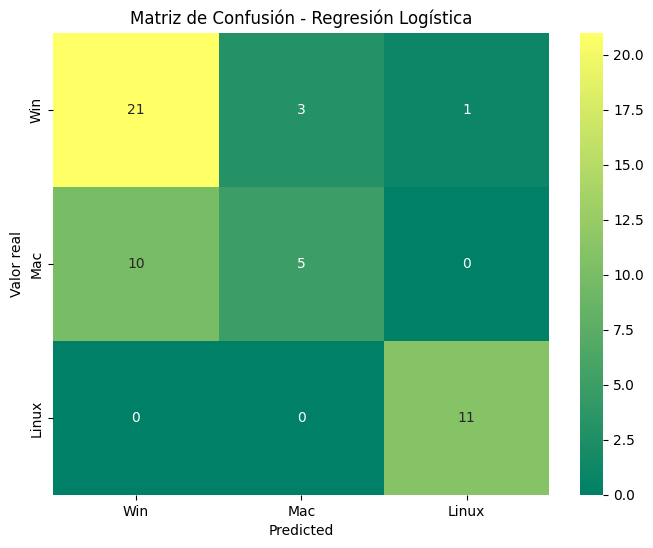

              precision    recall  f1-score   support

           0       0.68      0.84      0.75        25
           1       0.62      0.33      0.43        15
           2       0.92      1.00      0.96        11

    accuracy                           0.73        51
   macro avg       0.74      0.72      0.71        51
weighted avg       0.71      0.73      0.70        51



In [77]:
#separar los datos en variables predictoras y variable objetivo
X = dat_csv.drop('clase', axis=1)
Y = dat_csv['clase']
#dividir los datos en conjuntos de entrenamiento y prueba
#test_size=0.3 significa que el 30% de los datos se utilizarán para la prueba y el 70% para el entrenamiento
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)
#crear el modelo de regresión logística
#max_iter=1000 significa que el modelo se entrenará durante un máximo de 1000 iteraciones para encontrar los coeficientes óptimos
logistic_reg = LogisticRegression(max_iter=1000, solver='lbfgs')
#entrenar el modelo con los datos de entrenamiento
logistic_reg.fit(X_train, Y_train)
#predecir los resultados para el conjunto de prueba
Y_pred = logistic_reg.predict(X_test)

#matriz de confusión}
cm_logistica = confusion_matrix(Y_test, Y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm_logistica, annot=True, fmt='d', cmap='summer', xticklabels=['Win', 'Mac', 'Linux'], yticklabels=['Win', 'Mac', 'Linux'])
plt.title('Matriz de Confusión - Regresión Logística')
plt.xlabel('Predicted')
plt.ylabel('Valor real')
plt.show()

print(classification_report(Y_test, Y_pred))


Precisión la calidad de el modelo para Linux es del 92%  
Recall de Mac, tiene un recall muy bajo en Mac (33%)  
 Conclusión Técnica
El modelo es bueno identificando usuarios de Linux y aceptable con Windows, pero falla mucho con Mac, confundiéndolos casi siempre con Windows.  
